In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
import IPython.display
import os
import datetime as dt
from datetime import datetime
from tqdm import tqdm
import holidays, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
BRIGHT_BLACK = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
BRIGHT_WHITE = '\033[97m'
BRIGHT_END = '\033[0m'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


# model

In [2]:
# https://data.seoul.go.kr/dataList/OA-15182/F/1/datasetView.do#
path = 'data/서울시 공공자전거 대여이력 정보/1~6'

forder = os.listdir(path)

data1 = pd.DataFrame()

for files in tqdm(forder):
    data_ = pd.read_csv(path+'/'+files, encoding='cp949')
    data1 = pd.concat([data1, data_])

path = 'data/서울시 공공자전거 대여이력 정보/7~12'

forder = os.listdir(path)

data2 = pd.DataFrame()

for files in tqdm(forder):
    data_ = pd.read_csv(path+'/'+files, encoding='cp949')
    data2 = pd.concat([data2, data_])

100%|██████████| 6/6 [06:20<00:00, 63.43s/it]


In [118]:
display(data1.head(2))  
display(data2.head(2))

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,대여거치대,반납일시,반납대여소번호,반납대여소명,반납거치대,이용시간,이용거리
0,SPB-33633,2022-01-02 16:02:42,3,중랑센터,0,2022-01-02 16:14:14,540,군자역 7번출구 베스트샵 앞,0,11,2419.63
1,SPB-49457,2022-01-06 08:09:11,3,중랑센터,0,2022-01-06 08:19:43,3,중랑센터,0,10,0.00


,자전거번호,대여일시,대여 대여소번호,대여 대여소명,대여거치대,반납일시,반납대여소번호,반납대여소명,반납거치대,이용시간(분),이용거리(M),생년,성별,이용자종류,대여대여소ID,반납대여소ID
0,SPB-81465,2022-07-01 00:01:06,1548,북서울 꿈의숲 서문,99,2022-07-01 00:01:39,01548,북서울 꿈의숲 서문,99,0,10.0,1989,M,내국인,ST-1725,ST-1725
1,SPB-55885,2022-07-01 00:01:59,409,누리꿈스퀘어 옆,0,2022-07-01 00:02:08,00409,누리꿈스퀘어 옆,0,0,0.0,2002,\N,내국인,ST-86,ST-86


In [23]:
# https://github.com/vuski/SeoulBikeStationLocation/tree/main
# https://data.seoul.go.kr/dataList/OA-13252/F/1/datasetView.do?utm_source=chatgpt.com#
bike_num = pd.read_csv('data/대여소위치.tsv', sep='\t', encoding='cp949')
display(bike_num.head(2))
# 강서구 대여소 번호만 남기기
gangseogu_num = list(bike_num[bike_num['address'].str.contains('강서구')]['stationIndex'].unique())

,stationIndex,name,address,lon,lat,desc
0,101,(구)합정동 주민센터,서울특별시 마포구 동교로8길 58,126.905754,37.549561,-
1,102,망원역 1번출구 앞,서울특별시 마포구 월드컵로 72,126.910454,37.556000,-


In [27]:
use1 = ['대여일시', '대여 대여소번호', '반납일시', '반납대여소번호', '이용시간', '이용거리']
use2 = ['대여일시', '대여 대여소번호', '반납일시', '반납대여소번호', '이용시간(분)', '이용거리(M)']
data1 = data1[use1]
data2 = data2[use2]
data2.rename(columns={'이용시간(분)': '이용시간', '이용거리(M)': '이용거리'}, inplace=True)

data1 = data1[data1['대여 대여소번호'].isin(gangseogu_num)]
data2 = data2[data2['대여 대여소번호'].isin(gangseogu_num)]
data = pd.concat([data1, data2])

In [29]:
data['대여일시'] = data['대여일시'].apply(lambda x: x[:13])
data['반납일시'] = data['반납일시'].apply(lambda x: x[:13])

error_cnt = 0

def convert(x):
    global error_cnt
    try:
        x = str(int(x))
        return x
    except:
        pass


data['반납대여소번호'] = data['반납대여소번호'].apply(convert)
data['대여 대여소번호'] = data['대여 대여소번호'].apply(convert)

In [31]:
with open('data/강서구_대여이력정보.pickle', 'wb') as f:
    pickle.dump(data, f)

In [32]:
def date_range(start, end):
    start = datetime.strptime(start, "%Y-%m-%d")
    end = datetime.strptime(end, "%Y-%m-%d")
    dates = []
    for date in pandas.date_range(start, periods=(end-start).days+1):
        date = date.strftime("%Y-%m-%d")

        for i in range(24):
            i = str(i)
            if int(i) < 10: i = '0' + i
            dates.append(date + ' ' + i)

    return dates

dates = date_range("2022-01-01", "2022-12-31")

rental_grouped = data.groupby(data['대여 대여소번호'])
return_grouped = data.groupby(data['반납대여소번호'])

final_data_dict = {}

for num in tqdm(gangseogu_num):
    try:
        rental_data = rental_grouped.get_group(str(num))
        return_data = return_grouped.get_group(str(num))
        rental_data_ = rental_data.groupby('대여일시')

        rental_data_dict = {}

        for d in rental_data_:
            time_df = d[1] # 특정 시간에서 데이터

            col_0 = time_df.iloc[0]['대여일시']
            col_1 = len(time_df)
            col_2 = time_df['이용거리'].sum()
            col_3 = time_df['이용시간'].sum()

            rental_data_dict[col_0] = [col_0, col_1, col_2, col_3]

        return_data_ = return_data.groupby('반납일시')

        return_data_dict = {}

        for d in return_data_:
            time_df = d[1]

            col_0 = time_df.iloc[0]['반납일시']
            col_1 = len(time_df)
            col_2 = time_df['이용거리'].sum()
            col_3 = time_df['이용시간'].sum()
            
            return_data_dict[col_0] = [col_0, col_1, col_2, col_3]

        new_data = []

        rental_data_keys = rental_data_dict.keys()
        return_data_keys = return_data_dict.keys()

        for t in dates:
            if t in rental_data_keys and t in return_data_keys:
                new_data.append(rental_data_dict[t] + return_data_dict[t][1:])
            elif t in rental_data_keys and t not in return_data_keys:
                new_data.append(rental_data_dict[t] + [0, 0, 0])
            elif t not in rental_data_keys and t in return_data_keys:
                new_data.append([t] + [0, 0, 0] + return_data_dict[t][1:])
            elif t not in rental_data_keys and t not in return_data_keys:
                new_data.append([t] + [0, 0, 0, 0, 0, 0])

        new_data = pd.DataFrame(
            new_data,
            columns=['시간대', '대여', '대여_이용거리', '대여_이용시간', '반납', '반납_이용거리', '반납_이용시간']
            )

        new_data['반납-대여'] = new_data['반납'] - new_data['대여']

        final_data_dict[str(num)] = new_data

    except Exception as e:
        print(e)

 11%|█         | 11/99 [00:58<06:49,  4.65s/it]

'1114'
'1115'


 19%|█▉        | 19/99 [01:25<05:12,  3.91s/it]

'1123'


 68%|██████▊   | 67/99 [1:07:10<10:00:28, 1125.88s/it]

'2714'


100%|██████████| 99/99 [1:11:27<00:00, 43.30s/it]     


In [47]:
with open('data/강서구_시간대여소별_대여이력정보.pickle', 'wb') as f:
    pickle.dump(final_data_dict, f)

# 모델 학습

In [4]:
wth = pd.read_csv('data/final_weather.csv')  
wth.drop(columns=['Unnamed: 0'], inplace=True)  
wth['datetime'] = pd.to_datetime(wth['datetime'])
wth = wth[['datetime','temp','humid','미세먼지(PM10)','초미세먼지(PM2.5)']]
wth.drop(columns = ['datetime'], inplace=True)

In [5]:
wth

,temp,humid,미세먼지(PM10),초미세먼지(PM2.5)
0,-9.0,48.0,22.0,7.0
1,-11.0,62.0,29.0,10.0
2,-11.0,62.0,25.0,9.0
3,-12.0,61.0,27.0,9.0
4,-13.0,72.0,20.0,7.0
...,...,...,...,...
8755,-1.0,69.0,52.0,29.0
8756,-4.0,74.0,57.0,33.0
8757,-3.0,80.0,53.0,34.0
8758,-4.0,86.0,57.0,36.0


In [14]:
with open('data/강서구_시간대여소별_대여이력정보.pickle', 'rb') as f:
    data1 = pickle.load(f)

In [15]:
use_features = ['대여', '대여_이용거리', '대여_이용시간', '반납', '반납_이용거리', '반납_이용시간', '반납-대여']

window_size = 4 # 연속된 window_size개의 데이터를 가지고 다음 값 예측
input_size = len(use_features) + 4 # input 데이터 차원
hidden_size = 36 # lstm hidden state 차원
num_layers = 2 # lstm 쌓은 층
output_size = 1 # output 차원
dropout = 0.2
lr = 0.003
total_epochs = 500
batch_size = 10000
train_val_ratio = 0.9

In [16]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, scaler, window_size):
        self.scaler = scaler
        if self.scaler:
            data = self.scaler.transform(data)
        else:
            self.scaler = StandardScaler()
            data = self.scaler.fit_transform(data)
        
        x, y = [], []
        for i in range(len(data) - window_size):
            x.append(data[i:i+window_size])
            y.append(data[i+window_size, 6])
        
        self.x = torch.tensor(x, dtype=torch.float32, device=device)
        self.y = torch.tensor(y, dtype=torch.float32, device=device)
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
    

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h_0 = torch.zeros(self.num_layers, x.shape[0], self.hidden_size).to(device)
        c_0 = torch.zeros(self.num_layers, x.shape[0], self.hidden_size).to(device)
        x, _ = self.lstm(x, (h_0, c_0))
        x = self.linear(x[:, -1])
        return x
    
class Trainer:
    def __init__(self, model, train_loader, val_loader):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.loss = nn.MSELoss().to(device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.loss_history = {'train': [], 'val': []}
    
    def train(self):
        min_val_loss = None
        cnt = 0
        for epoch in range(total_epochs):
            print(f'Epoch: {epoch:02}')

            train_loss = self.train_step()
            print(f'\tTrain Loss: {train_loss:.5f}')

            val_loss = self.val_step()
            print(f'\tVal Loss: {val_loss:.5f}')

            self.loss_history['train'].append(train_loss)
            self.loss_history['val'].append(val_loss)
            
            if min_val_loss is None or val_loss < min_val_loss:
                min_val_loss = val_loss
                cnt = 0
            else:
                cnt += 1
            print(f'patience: {cnt}')
            if cnt >= 10:
                print('Early stopped!')
                break
    
    def train_step(self):
        self.model.train()

        epoch_loss = 0
        bar = tqdm(self.train_loader)

        for batch in bar:
            self.optimizer.zero_grad()

            x, y = batch
            outputs = self.model(x)

            loss = self.loss(outputs.squeeze(), y)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            bar.set_description(f'Train Loss: {loss.item():.5f}')
            epoch_loss += loss.item()

        epoch_loss /= len(self.train_loader)
        return epoch_loss
    
    def val_step(self):
        self.model.eval()

        epoch_loss = 0
        bar = tqdm(self.val_loader)

        for batch in bar:
            x, y = batch
            outputs = self.model(x)
            loss = self.loss(outputs.squeeze(), y)
            bar.set_description(f'Val Loss: {loss.item():.5f}')
            epoch_loss += loss.item()
            
        epoch_loss /= len(self.val_loader)
        return epoch_loss

In [9]:
display(data1['1101'].head(2))
print(data1['1101'].shape)

,시간대,대여,대여_이용거리,대여_이용시간,반납,반납_이용거리,반납_이용시간,반납-대여
0,2022-01-01 00,0,0.0,0,0,0.0,0,0
1,2022-01-01 01,0,0.0,0,0,0.0,0,0


(8760, 8)


In [21]:
testdata_dict = {}
dataset_dict = {}
scaler = StandardScaler()
all_train_data = []

for k, d in tqdm(data1.items()):
    d = pd.concat([d[use_features], wth], axis=1)
    all_train_data.append(d.iloc[:-24*7, :])  # 훈련 부분만 추출
    testdata_dict[k] = d.iloc[-24*7:, :].reset_index(drop=True)  # last week 는 test data

display(d.head(2))

scaler.fit(pd.concat(all_train_data, axis=0))

for k, d in tqdm(data1.items()):
    d = pd.concat([d[use_features], wth], axis=1)
    dataset_dict[k] = TimeSeriesDataset(d.iloc[:-24*7, :], scaler=scaler, window_size=window_size)

dataset = ConcatDataset(list(dataset_dict.values()))
     

100%|██████████| 95/95 [00:00<00:00, 575.17it/s]


,대여,대여_이용거리,대여_이용시간,반납,반납_이용거리,반납_이용시간,반납-대여,temp,humid,미세먼지(PM10),초미세먼지(PM2.5)
0,2,1747.51,12,2,3826.78,20,0,-9.0,48.0,22.0,7.0
1,1,0.00,19,0,0.00,0,-1,-11.0,62.0,29.0,10.0


100%|██████████| 95/95 [00:08<00:00, 10.90it/s]


In [27]:
train_dataset, val_dataset = random_split(dataset, [train_val_ratio, 1-train_val_ratio])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

model = LSTMModel(input_size, hidden_size, num_layers, output_size, dropout)
model.to(device)

trainer = Trainer(model=model, train_loader=train_loader, val_loader=val_loader)

trainer.train()
torch.save(model.state_dict(), 'lstm_all_features_standard.pt')

Epoch: 00


Train Loss: 0.89364: 100%|██████████| 74/74 [00:12<00:00,  5.98it/s]


	Train Loss: 0.79406


Val Loss: 0.70327: 100%|██████████| 9/9 [00:01<00:00,  6.56it/s]


	Val Loss: 0.72022
patience: 0
Epoch: 01


...

	Val Loss: 0.55948
patience: 9
Epoch: 38


Train Loss: 0.57965: 100%|██████████| 74/74 [00:11<00:00,  6.47it/s]


	Train Loss: 0.51823


Val Loss: 0.65690: 100%|██████████| 9/9 [00:01<00:00,  5.94it/s]

	Val Loss: 0.55427
patience: 10
Early stopped!


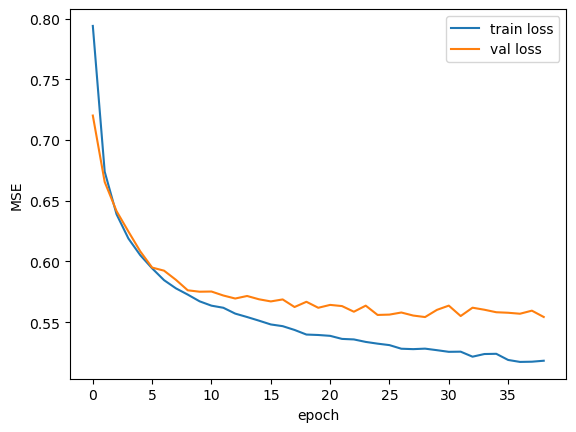

In [28]:
plt.plot(range(len(trainer.loss_history['train'])), trainer.loss_history['train'], label='train loss')
plt.plot(range(len(trainer.loss_history['train'])), trainer.loss_history['val'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

# Test

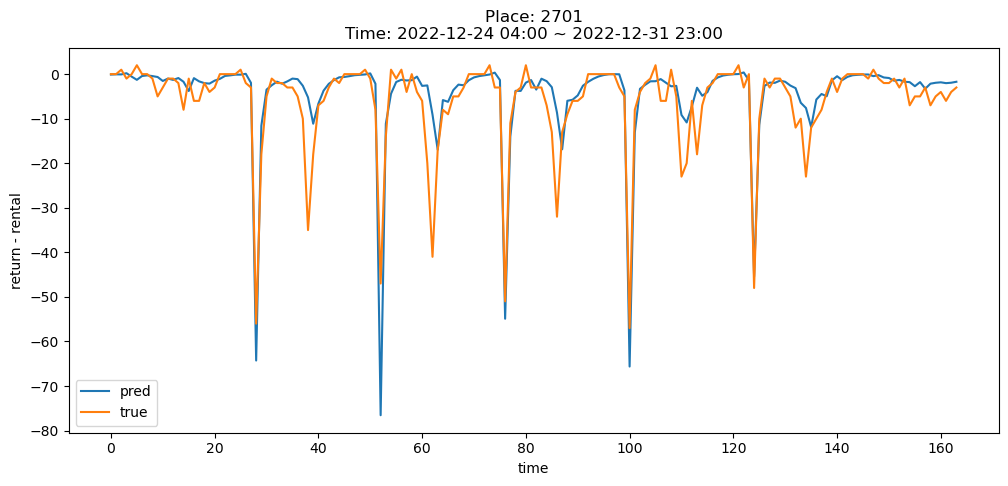

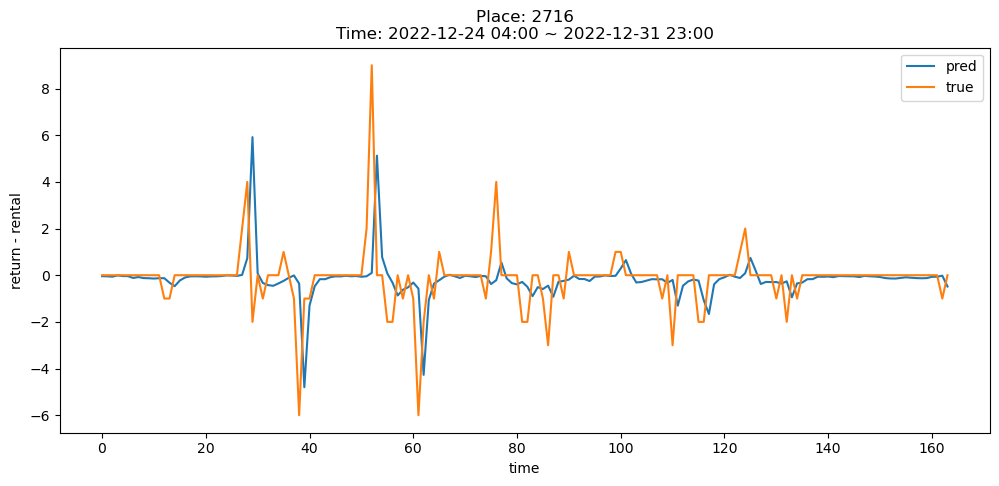

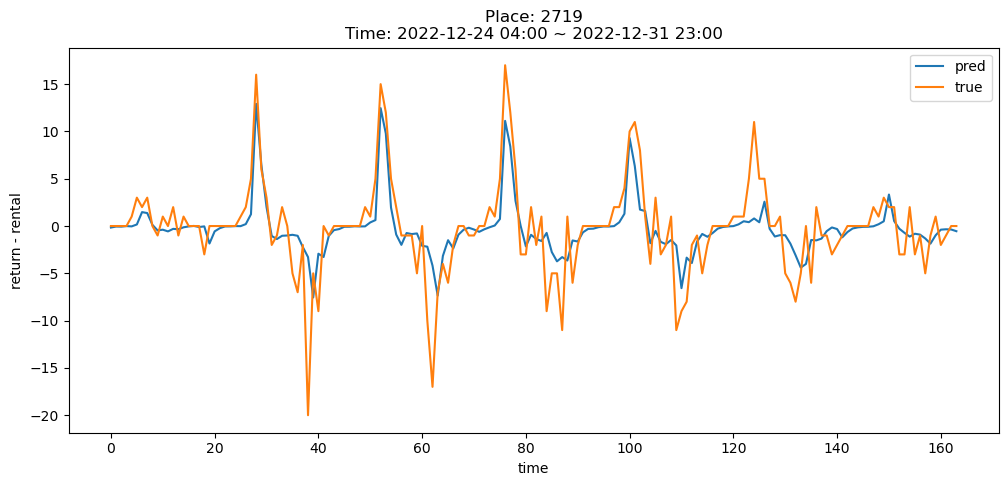

In [38]:
testdataset_dict = {}
for k, v in testdata_dict.items():
    testdataset_dict[k] = TimeSeriesDataset(v, scaler=scaler, window_size=window_size)

def predict(model, rental_place):
    model.eval()
    pred = model(testdataset_dict[rental_place].x)
    pred_with_dummy = torch.cat([torch.zeros((164, 6)), pred.to('cpu'), torch.zeros((164, 4))], axis=1).detach().numpy()
    pred = testdataset_dict[rental_place].scaler.inverse_transform(pred_with_dummy)[:, 6]
    return pred

model = LSTMModel(input_size, hidden_size, num_layers, output_size, dropout)
model.load_state_dict(torch.load('lstm_all_features_standard.pt'))
model.to(device)


def compare(model, target_place):
    pred = predict(model, target_place)
    plt.figure(figsize=(12, 5))

    plt.title(f'Place: {target_place}\nTime: 2022-12-24 04:00 ~ 2022-12-31 23:00')
    plt.xlabel('time')
    plt.ylabel('return - rental')
    plt.plot(pred, label='pred')
    plt.plot(testdata_dict[target_place]['반납-대여'].values[window_size:], label='true')
    plt.legend()
    
compare(model, '2701')
compare(model, '2716')
compare(model, '2719')

In [68]:
# 모든 대여소 예측값 저장
predicted_dict = {}
for sid in testdataset_dict:
    predicted_dict[sid] = predict(model, sid)
def find_predicted_supply_demand_pairs(predicted_dict, threshold=10):
    result = []
    station_ids = list(predicted_dict.keys())
    T = len(next(iter(predicted_dict.values())))  # 예측 시계열 길이

    for t in range(T):
        positives = []
        negatives = []
        for sid in station_ids:
            val = predicted_dict[sid][t]
            if val > threshold:
                positives.append((sid, val))
            elif val < -threshold:
                negatives.append((sid, val))

        for pos in positives:
            for neg in negatives:
                result.append((t, neg[0], pos[0]))  # 시간, 부족 대여소, 잉여 대여소
    return result
pairs = find_predicted_supply_demand_pairs(predicted_dict, threshold=10)
print(f"찾은 쌍 개수: {len(pairs)}")
print(pairs[:3])
# 예시: [(82, '3754', '1178')]
# 이면 82번째 시간에서
#    - 3754: 예측 수요 초과 (return - rental < -threshold)
#    - 1178: 예측 공급 여유 (return - rental > threshold)

# pairs 대여소 2개 쌍이 동일한거 있으면 제거
unique_pairs = set()
for t, neg, pos in pairs:
    if (neg, pos) not in unique_pairs and (pos, neg) not in unique_pairs:
        unique_pairs.add((neg, pos))
print(f"유니크한 쌍 개수: {len(unique_pairs)}")
print(unique_pairs)

찾은 쌍 개수: 7
[(28, '1162', '2719'), (28, '2701', '2719'), (28, '2715', '2719')]
유니크한 쌍 개수: 5
{('2701', '2719'), ('2701', '1193'), ('2715', '2719'), ('2715', '1193'), ('1162', '2719')}


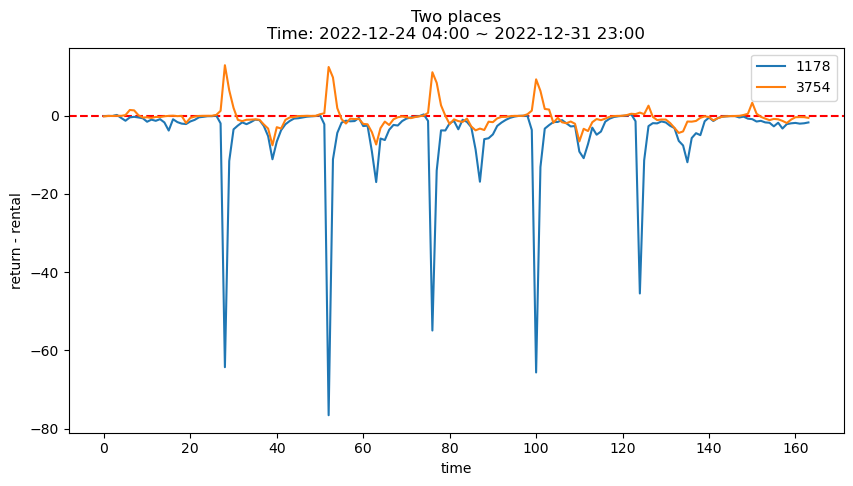

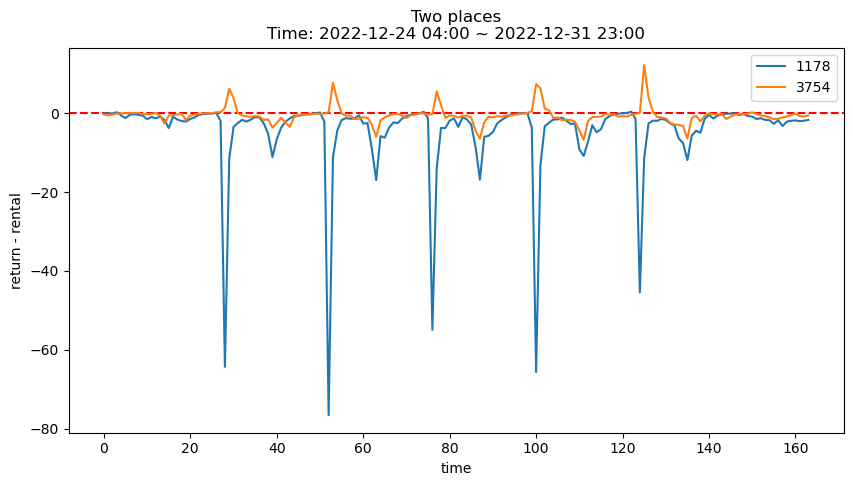

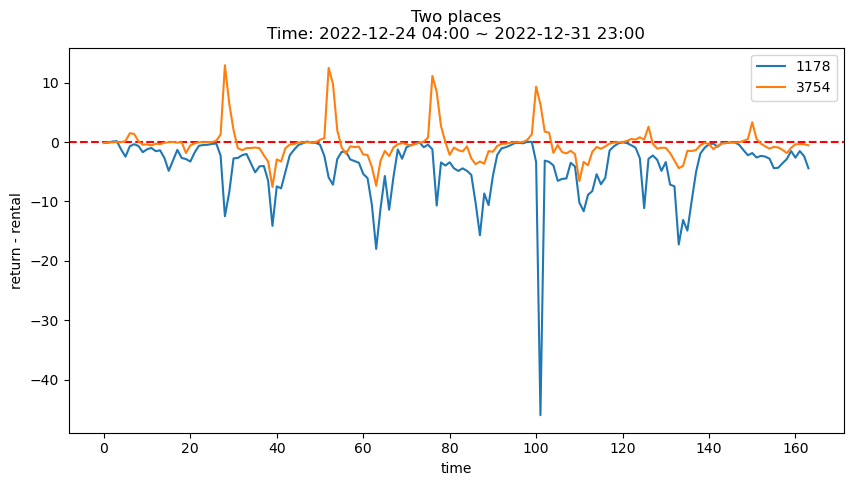

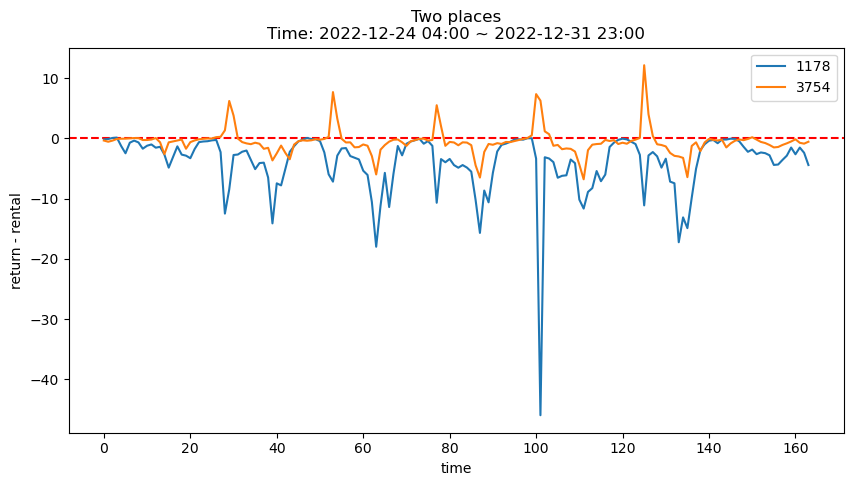

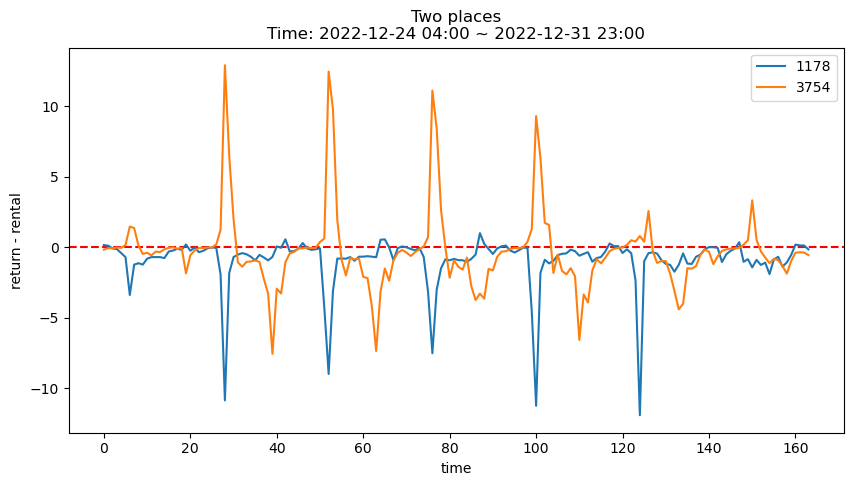

In [69]:
def trade(model, place1, place2):
    pred1 = predict(model, place1)
    pred2 = predict(model, place2)

    plt.figure(figsize=(10, 5))
    plt.title('Two places\nTime: 2022-12-24 04:00 ~ 2022-12-31 23:00')
    plt.xlabel('time')
    plt.axhline(0, color='red', linestyle='--')
    plt.ylabel('return - rental')
    plt.plot(pred1, label='1178')
    plt.plot(pred2, label='3754')
    plt.legend()

for place1, place2 in unique_pairs:
    trade(model, place1, place2)
    plt.show()